<a href="https://colab.research.google.com/github/PawanKumar1216/northstar-databases-analytics-assignment/blob/main/notebooks/06_Python_Data_Processing_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 Python Data Processing and Analysis

## NorthStar Urban Mobility and Logistics

This notebook applies Python data processing and analytical techniques to the NorthStar operational datasets. It uses Pandas, NumPy, Matplotlib, and Scikit-learn to clean data, engineer useful features, identify high-risk deliveries, profile drivers and hubs, analyse complaint behaviour, and detect operational anomalies.

## 1. Load Required Libraries and Import Dataset Files from GitHub

The NorthStar datasets are loaded directly from the project GitHub repository. Python libraries are used for data manipulation, numerical analysis, visualisation, and anomaly detection.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

# GitHub raw data URL
base_url = "https://raw.githubusercontent.com/PawanKumar1216/northstar-databases-analytics-assignment/main/data/"

# Load NorthStar dataset files directly from GitHub
customers = pd.read_csv(base_url + "customers.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
orders = pd.read_csv(base_url + "orders.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
hubs = pd.read_csv(base_url + "hubs.csv")

print("NorthStar datasets loaded successfully for Python analysis.")

NorthStar datasets loaded successfully for Python analysis.


## 2. Data Cleaning and Missing Value Handling

Before advanced analysis, the main datasets are checked for missing values. Missing customer ratings in the deliveries dataset are replaced using the mean rating, while missing delivery completion timestamps are filled with a clear placeholder value so that incomplete operational records can still be retained for analysis.

In [2]:
# Check missing values before cleaning
print("Missing values before cleaning in deliveries dataset:")
print(deliveries.isnull().sum())

# Store the original number of missing values
missing_ratings_before = deliveries["customer_rating_post_delivery"].isnull().sum()
missing_completion_before = deliveries["delivery_completed_at"].isnull().sum()

# Handle missing values
deliveries["customer_rating_post_delivery"] = deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].mean()
)

deliveries["delivery_completed_at"] = deliveries["delivery_completed_at"].fillna(
    "Not Completed"
)

# Check missing values after cleaning
print("\nMissing values after cleaning in deliveries dataset:")
print(deliveries.isnull().sum())

print(f"\nMissing customer ratings replaced: {missing_ratings_before}")
print(f"Missing delivery completion timestamps replaced: {missing_completion_before}")

Missing values before cleaning in deliveries dataset:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

Missing values after cleaning in deliveries dataset:
delivery_id                      0
order_id                         0
driver_id                        0
vehicle_id                       0
hub_id                           0
dispatch_time                    0
delivery_completed_at            0
delivery_status                  0
route_distance_km                0
manual_route_override_count      0
proof_of_completion_missing      0
customer_rating_post_deliv

## 3. Operational Inefficiency Score Analysis

A custom operational inefficiency score is created using several delivery-related variables: manual route overrides, route distance, fuel or charging cost, and missing proof of completion. This feature-engineering approach helps identify deliveries that consume more operational resources or show signs of process inefficiency.

In [3]:
# Create an operational inefficiency score
deliveries["inefficiency_score"] = (
    deliveries["manual_route_override_count"] * 2
    + deliveries["route_distance_km"] / 5
    + deliveries["fuel_or_charge_cost"] / 5
    + deliveries["proof_of_completion_missing"] * 3
)

# Display summary statistics for the new score
deliveries["inefficiency_score"].describe()

,inefficiency_score
count,950.000000
mean,7.506964
std,3.419148
min,0.762000
25%,5.059500
50%,6.908000
75%,9.235500
max,24.454000


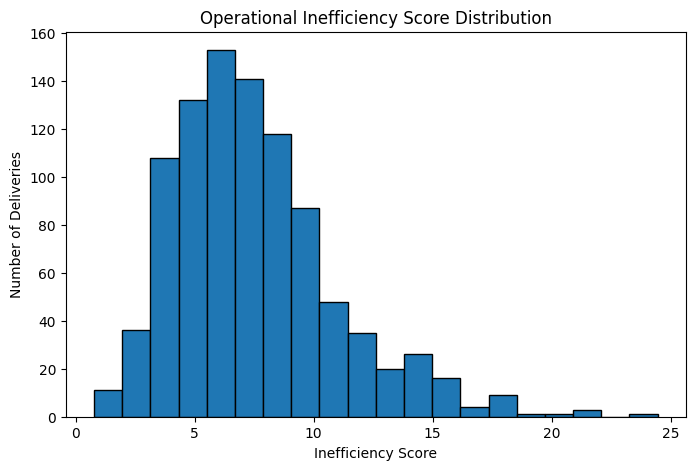

In [4]:
# Plot distribution of operational inefficiency scores
plt.figure(figsize=(8, 5))
plt.hist(deliveries["inefficiency_score"], bins=20, edgecolor="black")
plt.title("Operational Inefficiency Score Distribution")
plt.xlabel("Inefficiency Score")
plt.ylabel("Number of Deliveries")
plt.show()

## 4. High-Risk Delivery Detection

A delivery risk score is created using delivery status, route override frequency, and missing proof of completion. This allows the most operationally risky delivery records to be identified for priority review.

In [5]:
# Create a high-risk delivery score
deliveries["delivery_risk_score"] = (
    deliveries["manual_route_override_count"] * 2
    + deliveries["proof_of_completion_missing"] * 3
    + np.where(deliveries["delivery_status"] == "Failed", 4, 0)
    + np.where(deliveries["delivery_status"] == "Delayed", 2, 0)
)

# Identify the top 10 highest-risk deliveries
high_risk_deliveries = deliveries[
    [
        "delivery_id",
        "hub_id",
        "delivery_status",
        "manual_route_override_count",
        "proof_of_completion_missing",
        "delivery_risk_score"
    ]
].sort_values(by="delivery_risk_score", ascending=False).head(10)

high_risk_deliveries

,delivery_id,hub_id,delivery_status,manual_route_override_count,proof_of_completion_missing,delivery_risk_score
880,DL00881,H01,Delayed,5,1,15
54,DL00055,H04,Delayed,5,1,15
921,DL00922,H07,Delayed,5,1,15
472,DL00473,H07,OnTime,7,0,14
305,DL00306,H07,Delayed,4,1,13
514,DL00515,H04,Failed,3,1,13
504,DL00505,H08,Failed,3,1,13
40,DL00041,H08,Failed,3,1,13
730,DL00731,H05,Failed,3,1,13
788,DL00789,H06,Failed,3,1,13


## 5. Driver Risk Profiling

Driver risk is analysed by combining average route override behaviour, customer ratings, and average operational cost. This helps identify drivers who may be linked with lower service quality or higher operational inefficiency.

In [6]:
# Merge delivery data with driver information
driver_analysis = deliveries.merge(drivers, on="driver_id", how="left")

# Create driver-level summary
driver_risk = driver_analysis.groupby("driver_id").agg(
    total_deliveries=("delivery_id", "count"),
    average_route_overrides=("manual_route_override_count", "mean"),
    average_customer_rating=("customer_rating_post_delivery", "mean"),
    average_operational_cost=("fuel_or_charge_cost", "mean")
).reset_index()

# Keep drivers with at least 5 deliveries for more reliable comparison
driver_risk = driver_risk[driver_risk["total_deliveries"] >= 5].copy()

# Calculate combined driver risk score
driver_risk["driver_risk_score"] = (
    driver_risk["average_route_overrides"] * 2
    + driver_risk["average_operational_cost"] / 5
    + (5 - driver_risk["average_customer_rating"]) * 2
)

# Show top 10 highest-risk drivers
top_driver_risk = driver_risk.sort_values(
    by="driver_risk_score",
    ascending=False
).head(10)

top_driver_risk.round(2)

,driver_id,total_deliveries,average_route_overrides,average_customer_rating,average_operational_cost,driver_risk_score
126,D127,6,2.83,4.10,14.14,10.28
129,D130,8,2.00,3.81,15.27,9.44
68,D069,7,2.00,3.94,16.58,9.44
27,D028,7,1.86,3.54,13.84,9.41
26,D027,6,1.83,3.64,14.26,9.23
99,D100,8,1.25,3.35,16.27,9.06
164,D165,6,1.33,2.98,11.04,8.92
138,D139,5,2.00,4.08,14.36,8.70
130,D131,9,1.67,3.66,13.16,8.65
97,D098,5,1.40,3.59,14.95,8.60


## 6. Hub Operational Risk Analysis

Hub-level operational risk is analysed by combining route override behaviour, average operational cost, proof-of-completion issues, and non-on-time delivery rates. This helps identify which hubs require priority management attention.

In [7]:
# Create hub-level operational risk summary
hub_risk = deliveries.groupby("hub_id").agg(
    total_deliveries=("delivery_id", "count"),
    average_route_overrides=("manual_route_override_count", "mean"),
    average_operational_cost=("fuel_or_charge_cost", "mean"),
    missing_proof_rate=("proof_of_completion_missing", "mean"),
    non_on_time_rate=("delivery_status", lambda x: x.isin(["Delayed", "Failed"]).mean())
).reset_index()

# Calculate combined hub risk score
hub_risk["hub_risk_score"] = (
    hub_risk["average_route_overrides"] * 2
    + hub_risk["average_operational_cost"] / 5
    + hub_risk["missing_proof_rate"] * 5
    + hub_risk["non_on_time_rate"] * 5
)

# Add hub names
hub_risk = hub_risk.merge(hubs[["hub_id", "hub_name"]], on="hub_id", how="left")

# Sort by risk score
hub_risk = hub_risk.sort_values(by="hub_risk_score", ascending=False)

hub_risk.round(2)

,hub_id,total_deliveries,average_route_overrides,average_operational_cost,missing_proof_rate,non_on_time_rate,hub_risk_score,hub_name
4,H05,115,0.95,13.69,0.09,0.42,7.15,Central Core
5,H06,104,0.91,13.32,0.10,0.40,6.99,Airport Hub
7,H08,128,1.11,11.71,0.08,0.38,6.83,Midtown Relay
6,H07,115,1.05,12.92,0.08,0.34,6.78,Riverside Hub
1,H02,106,0.92,12.57,0.08,0.34,6.42,South Link
0,H01,136,1.03,12.76,0.04,0.32,6.41,North Exchange
3,H04,127,0.87,13.17,0.06,0.35,6.39,West Gate
2,H03,119,0.89,12.74,0.08,0.29,6.14,East Dock


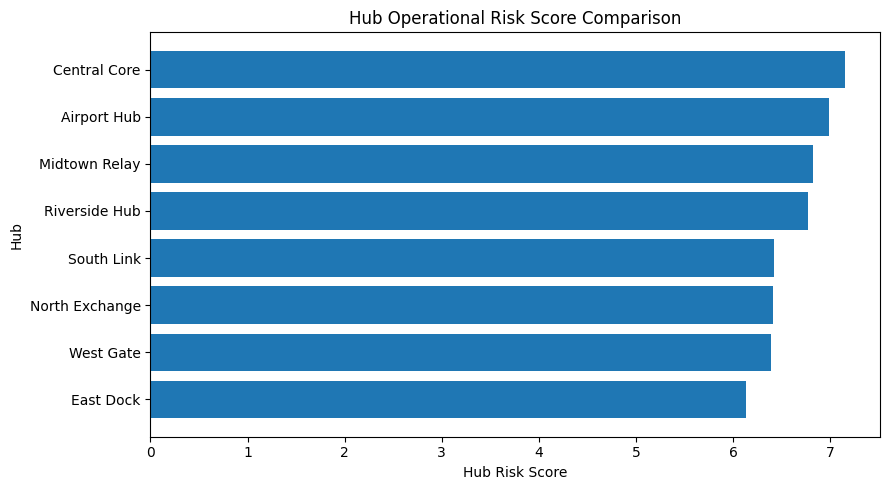

In [8]:
# Plot hub operational risk scores
hub_risk_plot = hub_risk.sort_values(by="hub_risk_score", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(hub_risk_plot["hub_name"], hub_risk_plot["hub_risk_score"])
plt.title("Hub Operational Risk Score Comparison")
plt.xlabel("Hub Risk Score")
plt.ylabel("Hub")
plt.tight_layout()
plt.show()

## 7. Complaint Behaviour Analysis

Complaint behaviour is analysed by linking complaints with delivery outcomes. This helps determine whether delayed or failed deliveries are associated with higher customer complaint activity and stronger customer-service consequences.

In [13]:
# Merge deliveries with complaints through order_id
delivery_complaints = deliveries.merge(
    complaints,
    on="order_id",
    how="left"
)

# Count total deliveries by status
total_deliveries_by_status = delivery_complaints.groupby("delivery_status")["delivery_id"].nunique()

# Count unique deliveries with at least one complaint by status
deliveries_with_complaints_by_status = (
    delivery_complaints[delivery_complaints["complaint_id"].notna()]
    .groupby("delivery_status")["delivery_id"]
    .nunique()
)

# Calculate complaint metrics by delivery status
complaint_metrics = delivery_complaints.groupby("delivery_status").agg(
    total_complaints=("complaint_id", "count"),
    average_compensation=("compensation_amount", "mean"),
    average_resolution_days=("resolution_days", "mean")
)

# Combine into one summary table
complaint_behaviour = complaint_metrics.copy()
complaint_behaviour["total_deliveries"] = total_deliveries_by_status
complaint_behaviour["deliveries_with_complaints"] = deliveries_with_complaints_by_status
complaint_behaviour["complaint_rate_percentage"] = (
    complaint_behaviour["deliveries_with_complaints"]
    / complaint_behaviour["total_deliveries"] * 100
)

# Reorder columns and display
complaint_behaviour = complaint_behaviour[
    [
        "total_deliveries",
        "deliveries_with_complaints",
        "total_complaints",
        "average_compensation",
        "average_resolution_days",
        "complaint_rate_percentage"
    ]
].reset_index()

complaint_behaviour.round(2)

,delivery_status,total_deliveries,deliveries_with_complaints,total_complaints,average_compensation,average_resolution_days,complaint_rate_percentage
0,Delayed,202,45,48,18.36,7.62,22.28
1,Failed,132,33,35,25.47,9.66,25.00
2,OnTime,616,131,149,19.18,7.60,21.27


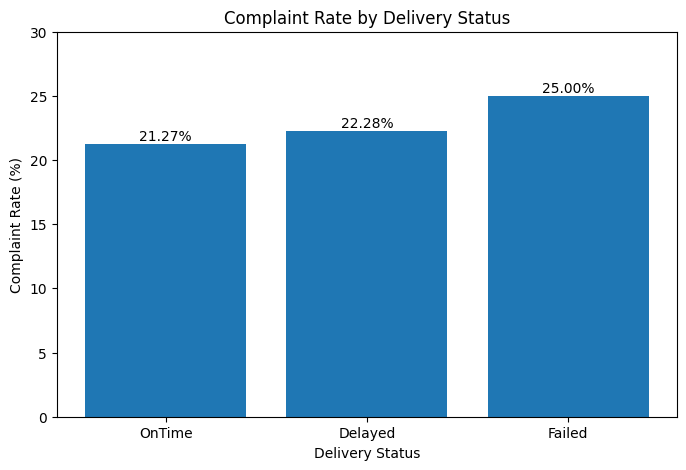

In [14]:
# Plot complaint rate by delivery status
complaint_plot = complaint_behaviour.sort_values(
    by="complaint_rate_percentage",
    ascending=True
)

plt.figure(figsize=(8, 5))
plt.bar(
    complaint_plot["delivery_status"],
    complaint_plot["complaint_rate_percentage"]
)
plt.title("Complaint Rate by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Complaint Rate (%)")

for i, value in enumerate(complaint_plot["complaint_rate_percentage"]):
    plt.text(i, value + 0.3, f"{value:.2f}%", ha="center")

plt.ylim(0, max(complaint_plot["complaint_rate_percentage"]) + 5)
plt.show()

## 8. Operational Anomaly Detection

Machine learning-based anomaly detection is applied using the Isolation Forest algorithm. The model uses route distance, route override count, operational cost, and customer rating to identify deliveries with unusual operational patterns that may not be detected through standard summary analysis.

In [15]:
# Select variables for anomaly detection
anomaly_features = deliveries[
    [
        "route_distance_km",
        "manual_route_override_count",
        "fuel_or_charge_cost",
        "customer_rating_post_delivery"
    ]
]

# Build Isolation Forest model
isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Fit model and predict anomalies
deliveries["anomaly_flag"] = isolation_forest.fit_predict(anomaly_features)

# Convert model output into readable labels
deliveries["anomaly_status"] = np.where(
    deliveries["anomaly_flag"] == -1,
    "Anomaly",
    "Normal"
)

# Show number of normal and anomalous deliveries
deliveries["anomaly_status"].value_counts()

,count
anomaly_status,
Normal,902
Anomaly,48


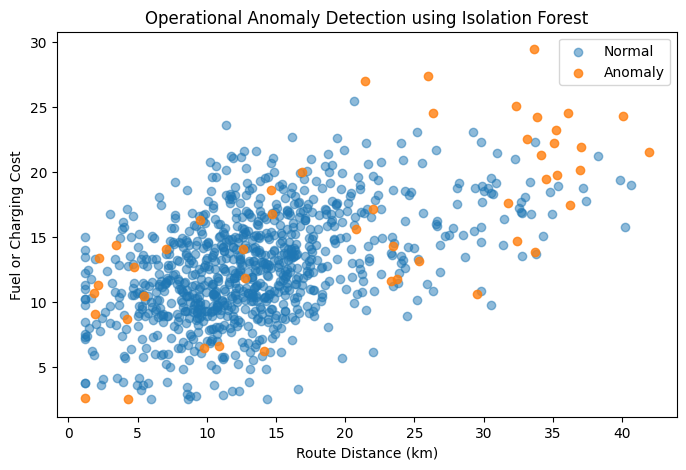

In [16]:
# Scatter plot of operational anomalies
plt.figure(figsize=(8, 5))

normal_deliveries = deliveries[deliveries["anomaly_status"] == "Normal"]
anomalous_deliveries = deliveries[deliveries["anomaly_status"] == "Anomaly"]

plt.scatter(
    normal_deliveries["route_distance_km"],
    normal_deliveries["fuel_or_charge_cost"],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    anomalous_deliveries["route_distance_km"],
    anomalous_deliveries["fuel_or_charge_cost"],
    alpha=0.8,
    label="Anomaly"
)

plt.title("Operational Anomaly Detection using Isolation Forest")
plt.xlabel("Route Distance (km)")
plt.ylabel("Fuel or Charging Cost")
plt.legend()
plt.show()

## 9. Exporting Analytical Results

The main analytical outputs are exported as CSV files so they can be reused for management reporting, further investigation, and future integration with other systems. This demonstrates that the Python workflow produces practical business outputs rather than only displaying results inside the notebook.

In [17]:
# Export key analytical results as CSV files
high_risk_deliveries.to_csv("high_risk_deliveries.csv", index=False)
top_driver_risk.to_csv("top_driver_risk.csv", index=False)
hub_risk.to_csv("hub_operational_risk.csv", index=False)
complaint_behaviour.to_csv("complaint_behaviour_by_delivery_status.csv", index=False)

print("Analytical result files exported successfully:")
print("- high_risk_deliveries.csv")
print("- top_driver_risk.csv")
print("- hub_operational_risk.csv")
print("- complaint_behaviour_by_delivery_status.csv")

Analytical result files exported successfully:
- high_risk_deliveries.csv
- top_driver_risk.csv
- hub_operational_risk.csv
- complaint_behaviour_by_delivery_status.csv


## 10. Review of Detected Anomalies

The anomalous delivery records are reviewed to understand which operational characteristics caused them to stand out. This helps convert the machine-learning output into practical business evidence for investigation.

In [18]:
# Display the top anomalous deliveries for investigation
anomalous_delivery_review = deliveries[
    deliveries["anomaly_status"] == "Anomaly"
][
    [
        "delivery_id",
        "hub_id",
        "delivery_status",
        "route_distance_km",
        "manual_route_override_count",
        "fuel_or_charge_cost",
        "customer_rating_post_delivery",
        "inefficiency_score"
    ]
].sort_values(
    by="inefficiency_score",
    ascending=False
).head(10)

anomalous_delivery_review.round(2)

,delivery_id,hub_id,delivery_status,route_distance_km,manual_route_override_count,fuel_or_charge_cost,customer_rating_post_delivery,inefficiency_score
54,DL00055,H04,Delayed,35.07,5,22.20,2.78,24.45
305,DL00306,H07,Delayed,34.53,4,19.47,2.96,21.80
428,DL00429,H07,Delayed,41.94,3,21.55,2.92,21.70
671,DL00672,H02,OnTime,35.33,5,19.77,4.94,21.02
805,DL00806,H07,Delayed,40.11,2,24.27,2.68,19.88
143,DL00144,H06,OnTime,25.98,4,27.38,4.84,18.67
921,DL00922,H07,Delayed,12.65,5,14.07,3.39,18.34
472,DL00473,H07,OnTime,14.15,7,6.22,4.01,18.07
880,DL00881,H01,Delayed,12.77,5,11.86,3.32,17.93
743,DL00744,H06,Delayed,25.36,5,13.11,1.64,17.69


## 11. Summary of Python Data Processing and Analysis

The Python workflow successfully demonstrated data cleaning, feature engineering, analytical profiling, visualisation, and machine-learning-based anomaly detection using the NorthStar operational datasets.

The data-cleaning stage identified and handled 19 missing delivery completion timestamps and 14 missing customer ratings. An operational inefficiency score was then engineered using route overrides, delivery distance, operational cost, and missing proof of completion. The score distribution showed a small group of unusually inefficient deliveries requiring further investigation.

High-risk delivery analysis identified records with repeated route overrides, missing delivery proof, and delayed or failed outcomes. Driver-risk profiling showed that D127, D130, and D069 had the highest combined risk scores, while hub-risk analysis confirmed that H05 Central Core, H06 Airport Hub, and H08 Midtown Relay were the highest-priority hubs for management review.

Complaint analysis showed that failed deliveries had the highest complaint rate at 25.00%, followed by delayed deliveries at 22.28%. The Isolation Forest model identified 48 anomalous delivery records, and the anomaly review showed that some deliveries were operationally inefficient even when they were completed on time.

Overall, the Python analysis moved beyond simple descriptive reporting by cleaning the data, engineering new features, ranking operational risks, detecting anomalies, and exporting management-ready analytical outputs.